<>:24: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?


default;kick;260108;0
default;kick;260108;1
default;kick;260108;2
default;kick;260108;3
default;kick;260108;4
default;kick;260108;5
default;kick;260108;6


C:\Users\felix\AppData\Local\Temp\ipykernel_11080\2054476733.py:24: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if go.action_name is "kick" and go.log_index == 0:


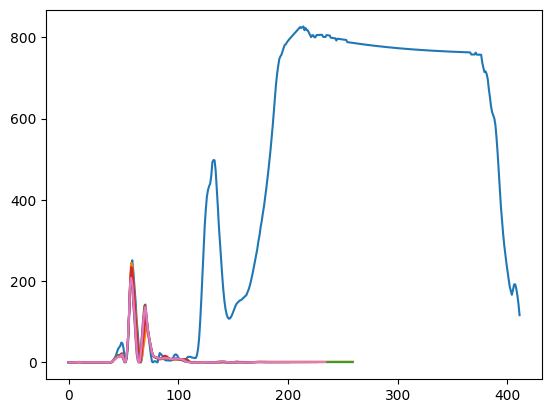

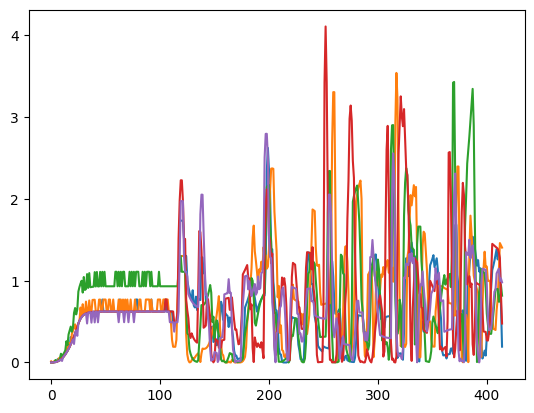

default;turn;260108;3


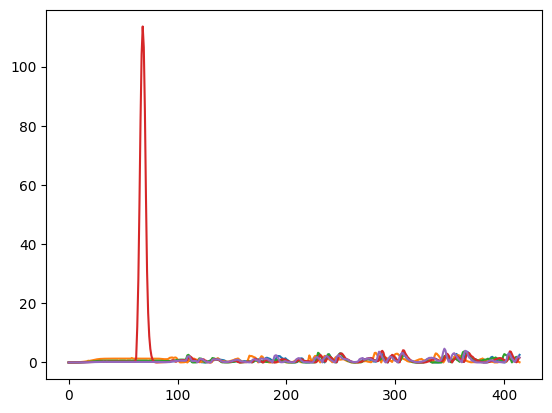

default;walk;260108;4


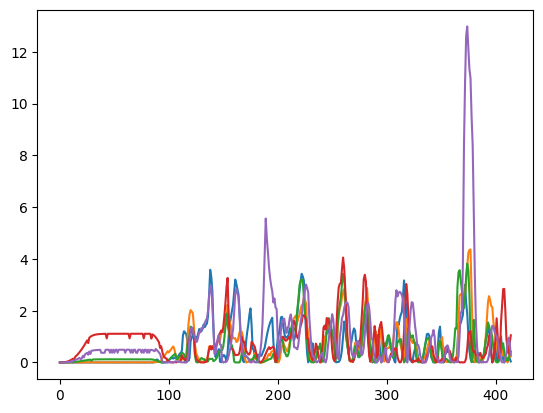

In [1]:
from fontTools.ttLib.tables.S__i_l_f import aCode_info

from src import *
import matplotlib.pyplot as plt
import numpy as np

logger = logging.getLogger("global_logger")
logging.basicConfig(filename='gap_analysis.log',format='%(levelname)s: %(message)s', encoding='utf-8', filemode='w', level=logging.DEBUG)
logger.info("NEW START")

action_names = ["kick", "sidestep", "turn", "walk"]


replay_settings = SimulationParameters("default")
simulator = Simulator()
gap_objects = simulator.simulation_gap(settings=replay_settings, action_names=action_names)
sorted_gos = [[go for go in gap_objects if go.action_name is action_name] for action_name in action_names]

hinges = ["lShoulderPitch", "rShoulderPitch"]
hinge = "lShoulderPitch"

for go_list in sorted_gos:
    for go in go_list:
        if go.action_name == "kick" and go.log_index == 0:
            continue
        go.load()
        p_gap = go.get_pos_gap([hinge])
        if max(p_gap[hinge]) > 5:
            print(go.identifier)
        x = range(0, len(p_gap[hinge]))
        plt.plot(x, p_gap[hinge])
        go.unload()
    plt.show()


In [ ]:
# kick objects
for go in gap_objects:
    go.load()
    p_gap = go.get_pos_gap([hinge])
    if max(p_gap[hinge]) > 5:
        print(go.identifier)
    x = range(0, len(p_gap[hinge]))
    plt.plot(x, p_gap[hinge])
    go.unload()